<a href="https://colab.research.google.com/github/academiaturkiye/academiaturkiye.github.io/blob/main/mesa/temel%20ajanlar/temel-teknik-gurultu-oran%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.3 MB/s eta 0:00:00


In [6]:
import random

# === FUNDAMENTAL AGENT STRATEGIES ===
def fundamental_strategy_0(agent, model):
    """Basit Değer Stratejisi: Fiyat < Temel Değerse al."""
    #print(f"Fundamental_strategy_0 aktif")
    if model.price < model.fundamental_value_0:
        return "buy"
    elif model.price > model.fundamental_value_0:
        return "sell"
    return "hold"

def fundamental_strategy_1(agent, model):
    """Basit Değer Stratejisi: Fiyat < Temel Değerse al."""
    #print(f"Fundamental_strategy_1 aktif")
    if model.price < model.fundamental_value_1:
        return "buy"
    elif model.price > model.fundamental_value_1:
        return "sell"
    return "hold"

def fundamental_strategy_2(agent, model):
    """Trend Takip (Fundamental bazlı): Temel değer artıyorsa al."""
    #print(f"Fundamental_strategy_2 aktif")
    if model.fundamental_value_2 > model.prev_fundamental_value_2:
        return "buy"
    elif model.fundamental_value_2 < model.prev_fundamental_value_2:
        return "sell"
    return "hold"

def fundamental_strategy_3(agent, model):
    """Asimetrik Temel Değere Göre al-sat-bekle"""
    #print(f"Fundamental_strategy_3 aktif")
    if model.price < model.fundamental_value_3:
        return "buy"
    elif model.price > model.fundamental_value_3:
        return "sell"
    return "hold"




fundamental_strategies = [
    fundamental_strategy_0,
    fundamental_strategy_1,
    fundamental_strategy_2,
    fundamental_strategy_3
]

# === TECHNICAL AGENT STRATEGIES ===
def technical_strategy_0(agent, model):
    """Basit Momentum: Fiyat yükseliyorsa al."""
    if model.price > model.prev_price:
        return "buy"
    elif model.price < model.prev_price:
        return "sell"
    return "hold"

def technical_strategy_1(agent, model):
    """Tersine Tepki: Fiyat düşüyorsa al."""
    if model.price < model.prev_price:
        return "buy"
    elif model.price > model.prev_price:
        return "sell"
    return "hold"

def technical_strategy_2(agent, model):
    """Rastgele Momentum: %60 ihtimalle trend takibi"""
    if random.random() < 0.6:
        return technical_strategy_0(agent, model)
    else:
        return "hold"

def technical_strategy_3(agent, model):
    """Trend Dönüşü: Son üç fiyatı analiz et."""
    history = model.price_history
    if len(history) >= 3:
        if history[-1] > history[-2] > history[-3]:
            return "sell"
        elif history[-1] < history[-2] < history[-3]:
            return "buy"
    return "hold"

technical_strategies = [
    technical_strategy_0,
    technical_strategy_1,
    technical_strategy_2,
    technical_strategy_3
]

# === NOISE AGENT STRATEGIES ===
def noise_strategy_0(agent, model):
    """Rastgele işlem."""
    return random.choice(["buy", "sell", "hold"])

def noise_strategy_1(agent, model):
    """Daha çok hold eğilimli rastgele işlem."""
    return random.choices(["buy", "sell", "hold"], weights=[0.2, 0.2, 0.6])[0]

def noise_strategy_2(agent, model):
    """Fiyatın çift/tek olmasına göre karar verir."""
    if int(model.price) % 2 == 0:
        return "buy"
    else:
        return "sell"

def noise_strategy_3(agent, model):
    """Rastgele ancak varlığı olanlar daha çok satar."""
    if agent.asset > 0 and random.random() < 0.6:
        return "sell"
    return random.choice(["buy", "hold"])

noise_strategies = [
    noise_strategy_0,
    noise_strategy_1,
    noise_strategy_2,
    noise_strategy_3
]

In [7]:

class BaseAgent(mesa.Agent):
    def __init__(self, model, agent_type, strategy_id):
        super().__init__(model)
        self.agent_type = agent_type  # 'fundamental', 'technical', 'noise'
        self.strategy_id = strategy_id  # 0, 1, 2, 3 (her tür için 4 strateji)
        self.cash = 1000.0
        self.asset = 0
        self.last_action = None  # 'buy', 'sell', 'hold'

    def step(self):
        raise NotImplementedError("This method should be implemented by subclasses.")


class FundamentalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "fundamental", strategy_id)

    def step(self):
        #from strategies import fundamental_strategies
        action = fundamental_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class TechnicalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "technical", strategy_id)

    def step(self):
        #from strategies import technical_strategies
        action = technical_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class NoiseAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "noise", strategy_id)

    def step(self):
        #from strategies import noise_strategies
        action = noise_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action

In [37]:

from mesa.datacollection import DataCollector
#from agents import FundamentalAgent, TechnicalAgent, NoiseAgent
#from strategies import fundamental_strategies, technical_strategies, noise_strategies
import random

class MarketModel(mesa.Model):
    def __init__(self,
                 num_fundamental=400,
                 num_technical=400,
                 num_noise=400,
                 initial_price=100,
                 initial_fundamental_value=100):
        super().__init__()

        # Initialize total_demand and total_supply attributes
        self.total_demand = 0
        self.total_supply = 0


        self.price = initial_price
        self.prev_price = initial_price
        self.fundamental_value_0= initial_fundamental_value
        self.fundamental_value_1 = initial_fundamental_value
        self.fundamental_value_2 = initial_fundamental_value
        self.fundamental_value_3 = initial_fundamental_value


        self.prev_fundamental_value_0= initial_fundamental_value
        self.prev_fundamental_value_1 = initial_fundamental_value
        self.prev_fundamental_value_2 = initial_fundamental_value
        self.prev_fundamental_value_3 = initial_fundamental_value

        self.price_history = [initial_price]
        self.fundamental_history_0 = [initial_fundamental_value]
        self.fundamental_history_1 = [initial_fundamental_value]
        self.fundamental_history_2 = [initial_fundamental_value]
        self.fundamental_history_3 = [initial_fundamental_value]

        self.step_count = 0
        self.news= 0
        self.score = 0

        # Haber dağılımı
        self.news_values = [-2, -1, 0, 1, 2]
        self.news_probs = [0.05, 0.20, 0.50, 0.20, 0.05]
        self.news_memory = []





        # Ajanları oluştur
        # Fundamental agents
        for i in range(num_fundamental):
            strat_index = i % 4
            agent = FundamentalAgent(self, strat_index)
            self.agents.add(agent)

        # Technical agents
        for i in range(num_technical):
            strat_index = i % 4
            agent = TechnicalAgent(self, strat_index)
            self.agents.add(agent)

        # Noise agents
        for i in range(num_noise):
            strat_index = i % 4
            agent = NoiseAgent(self, strat_index)
            self.agents.add(agent)


        self.datacollector = DataCollector(
            model_reporters={"Price": lambda m: m.price}
        )

    def update_fundamental_value_0(self):
        # Temel Etki
        imbalance = self.total_demand - self.total_supply
        if self.news > 0:
            news_0 = self.news * 0.1 * imbalance
        elif self.news < 0:
            news_0 = self.news * 0.1 * imbalance
        else:
            news_0 = 0

        print(f"Haber/Bilgi: {news_0}")
        self.prev_fundamental_value_0= self.fundamental_value_0
        self.fundamental_value_0 += news_0
        self.fundamental_history_0.append(self.fundamental_value_0)


    def update_fundamental_value_1(self):
        #Asimetrik Etki
        imbalance = self.total_demand - self.total_supply
        if self.news > 0:
            news_1 = self.news * 0.1 * imbalance
        elif self.news < 0:
            news_1 = self.news * 0.15 * imbalance # Negatif etki, pozitif etkiden daha büyük
        else:
            news_1 = 0

        print(f"Haber/Bilgi_1: {news_1}")
        self.prev_fundamental_value_1 = self.fundamental_value_1
        self.fundamental_value_1 += news_1
        self.fundamental_history_1.append(self.fundamental_value_1)

    def update_fundamental_value_2(self):
        # Güçlenen Etki
        imbalance = self.total_demand - self.total_supply
        self.score += self.news
        news_2 = self.score * 0.1 * imbalance

        print(f"Haber/Bilgi_2: {news_2}")
        self.prev_fundamental_value_2 = self.fundamental_value_2
        self.fundamental_value_2 += news_2
        self.fundamental_history_2.append(self.fundamental_value_2)

    def update_fundamental_value_3(self):
        # Sönümlü Etki
        imbalance = self.total_demand - self.total_supply
        # Son N haberi tut (hafıza penceresi)
        self.window =5
        if len(self.news_memory) > self.window:
            self.news_memory.pop(0)

        # Ağırlıklı ortalama hesapla
        if len(self.news_memory) < self.window:
            avg_signal = np.mean(self.news_memory)
        else:
            weights = np.arange(1, self.window + 1)  # [1, 2, 3, 4, 5]
            avg_signal = np.average(self.news_memory[-self.window:], weights=weights)

        news_3= avg_signal * 0.1 * imbalance

        print(f"Haber/Bilgi_3: {news_3}")
        self.prev_fundamental_value_3 = self.fundamental_value_3
        self.fundamental_value_3 += news_3
        self.fundamental_history_3.append(self.fundamental_value_3)




    def update_price(self, demand, supply):
        #Fiyatı arz-talep farkına göre günceller.
        imbalance = demand - supply
        self.prev_price = self.price
        self.price += 0.1 * imbalance  # Duyarlılık katsayısı
        self.price = max(1, self.price)  # Negatif fiyatı engelle
        self.price_history.append(self.price)

    def step(self):
        """Zaman adımını ilerletir."""
        self.step_count += 1
        self.update_fundamental_value_0()
        self.update_fundamental_value_1()
        self.update_fundamental_value_2()
        self.update_fundamental_value_3()


        self.total_demand = 0
        self.total_supply = 0

        self.news = np.random.choice(self.news_values, p=self.news_probs)
        self.news_memory.append(self.news)



        # Agent step method calls execute_action which updates model's total_demand/supply
        self.agents.do("step")


        # Print demand and supply before price update
        print(f"Step {self.step_count}: Demand = {self.total_demand}, Supply = {self.total_supply}")


        # Fiyat güncelle
        self.update_price(self.total_demand, self.total_supply)

        # Print price after update
        print(f"Step {self.step_count}: New Price = {self.price}")


        # Veri topla
        self.datacollector.collect(self)

    def run_model(self, steps=100):
        for _ in range(steps):
            self.step()







Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: nan
Step 1: Demand = 0, Supply = 0
Step 1: New Price = 100.0
Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 2: Demand = 0, Supply = 0
Step 2: New Price = 100.0
Haber/Bilgi: 0.0
Haber/Bilgi_1: 0.0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 3: Demand = 0, Supply = 0
Step 3: New Price = 100.0
Haber/Bilgi: 0.0
Haber/Bilgi_1: 0.0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 4: Demand = 0, Supply = 0
Step 4: New Price = 100.0
Haber/Bilgi: 0.0
Haber/Bilgi_1: 0.0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 5: Demand = 0, Supply = 0
Step 5: New Price = 100.0
Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 6: Demand = 0, Supply = 0
Step 6: New Price = 100.0
Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 7: Demand = 0, Supply = 0
Step 7: New Price = 100.0
Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 8: Demand = 0, Supply = 

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


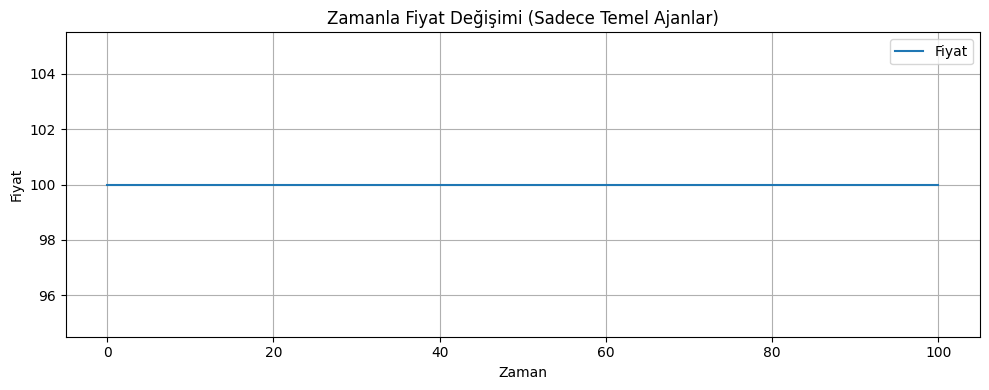

In [40]:

import matplotlib.pyplot as plt

# Sadece temel ajanlarla simülasyon
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100)

# Fiyatları çiz
price_history = model.price_history
plt.figure(figsize=(10, 4))
plt.plot(price_history, label="Fiyat")
plt.title("Zamanla Fiyat Değişimi (Sadece Temel Ajanlar)")
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: nan
Step 1: Demand = 0, Supply = 0
Step 1: New Price = 100.0
Haber/Bilgi: -0.0
Haber/Bilgi_1: -0.0
Haber/Bilgi_2: -0.0
Haber/Bilgi_3: -0.0
Step 2: Demand = 0, Supply = 0
Step 2: New Price = 100.0
Haber/Bilgi: 0.0
Haber/Bilgi_1: 0.0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 3: Demand = 0, Supply = 0
Step 3: New Price = 100.0
Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 4: Demand = 0, Supply = 0
Step 4: New Price = 100.0
Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 5: Demand = 0, Supply = 0
Step 5: New Price = 100.0
Haber/Bilgi: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 6: Demand = 0, Supply = 0
Step 6: New Price = 100.0
Haber/Bilgi: -0.0
Haber/Bilgi_1: -0.0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: -0.0
Step 7: Demand = 0, Supply = 0
Step 7: New Price = 100.0
Haber/Bilgi: 0.0
Haber/Bilgi_1: 0.0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: 0.0
Step 8: Demand = 0

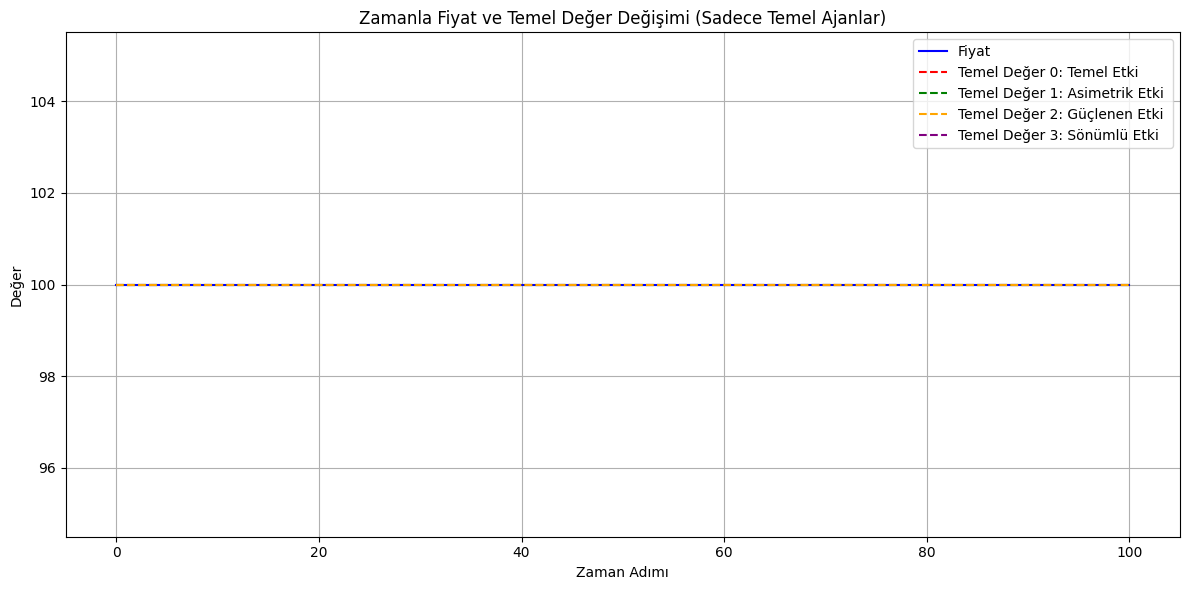

In [39]:
import matplotlib.pyplot as plt
# MarketModel sınıfınızın tanımlandığından emin olun (önceki hücreyi çalıştırarak)
# Agent ve strategy tanımlarının da yapıldığından emin olun

# Sadece temel ajanlarla simülasyon
# Daha önce düzeltilen MarketModel sınıfını kullanın
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100)

# Fiyatları ve Temel Değeri çiz
price_history = model.price_history
fundamental_history_0= model.fundamental_history_0 # Temel değer geçmişini al
fundamental_history_1= model.fundamental_history_1 # Temel değer geçmişini al
fundamental_history_2= model.fundamental_history_2 # Temel değer geçmişini al
fundamental_history_3= model.fundamental_history_3 # Temel değer geçmişini al




plt.figure(figsize=(12, 6)) # Grafik boyutunu büyütelim
plt.plot(price_history, label="Fiyat", color='blue')
plt.plot(fundamental_history_0, label="Temel Değer 0: Temel Etki", color='red', linestyle='--') # Temel değeri kesikli çizgiyle ekle
plt.plot(fundamental_history_1, label="Temel Değer 1: Asimetrik Etki", color='green', linestyle='--') # Temel değeri kesikli çizgiyle ekle
plt.plot(fundamental_history_2, label="Temel Değer 2: Güçlenen Etki ", color='orange', linestyle='--') # Temel değeri kesikli çizgiyle ekle
plt.plot(fundamental_history_3, label="Temel Değer 3: Sönümlü Etki", color='purple', linestyle='--') # Temel değeri kesikli çizgiyle ekle



plt.title("Zamanla Fiyat ve Temel Değer Değişimi (Sadece Temel Ajanlar)")
plt.xlabel("Zaman Adımı")
plt.ylabel("Değer")
plt.grid(True)
plt.legend()
plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()


Modeller:
- Sabit
- Asimetrik
- Hafızalı
- Sönümlü
- Güçlenen

Bu modellerin teorik açıklamarı ile birlikte tezde yer ver. Örneğin hafızalı-fiyat keşif süreci
